# Mini-proyecto: Predecir resultados de la F1 usando carreras pasadas
**Objetivo:** Predecir la posicion final (top 3, top 10) usando datos de carreras anteriores

El modelo esta entrenado para responder la pregunta:
__¿Quiénes estarán en el podio en esta carrera específica (ej: Bahrain)?__


In [1]:
import os
import fastf1
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

from fastf1.events import get_event_schedule

In [2]:
# Enable FastF1 caching
cache_folder = 'cache_folder'
if not os.path.exists(cache_folder):
    os.makedirs(cache_folder)

fastf1.Cache.enable_cache(cache_folder)

## Paso 1: Obtener datos de varias carreras
Utilizando |FastF1| para recorrer múltiples carreras de una o varias temporadas.

In [3]:
# Quick test

# Comprobar el calendario de una temporada
def check_season_schedule(year):
    try:
        schedule = fastf1.get_event_schedule(year)
        print(schedule.head())
    except Exception as e:
        print(f"No se pudo cargar el calendario para {year}: {e}")

# Comprobar calendarios para 2022 y 2023
check_season_schedule(2023)
check_season_schedule(2022)

   RoundNumber       Country   Location  \
0            0       Bahrain     Sakhir   
1            1       Bahrain     Sakhir   
2            2  Saudi Arabia     Jeddah   
3            3     Australia  Melbourne   
4            4    Azerbaijan       Baku   

                             OfficialEventName  EventDate  \
0     FORMULA 1 ARAMCO PRE-SEASON TESTING 2023 2023-02-25   
1   FORMULA 1 GULF AIR BAHRAIN GRAND PRIX 2023 2023-03-05   
2  FORMULA 1 STC SAUDI ARABIAN GRAND PRIX 2023 2023-03-19   
3   FORMULA 1 ROLEX AUSTRALIAN GRAND PRIX 2023 2023-04-02   
4         FORMULA 1 AZERBAIJAN GRAND PRIX 2023 2023-04-30   

                  EventName      EventFormat    Session1  \
0        Pre-Season Testing          testing  Practice 1   
1        Bahrain Grand Prix     conventional  Practice 1   
2  Saudi Arabian Grand Prix     conventional  Practice 1   
3     Australian Grand Prix     conventional  Practice 1   
4     Azerbaijan Grand Prix  sprint_shootout  Practice 1   

             

In [4]:
# Obtener datos de una carrera
def get_race_data(year, round_name):
    try:
        session = fastf1.get_session(year, round_name, 'R')
        session.load()
        results = session.results
        results['Race'] = round_name
        results['Year'] = year
        return results
    except Exception as e:
        print(f"Error en {year} - Ronda {round_name}: {e}")
        return pd.DataFrame()

# Lista explícita de carreras para 2022 y 2023
carreras_2022 = [
    'Bahrain', 'Saudi Arabia', 'Australia', 'Emilia Romagna', 'Miami',
    'Spain', 'Monaco', 'Azerbaijan', 'Canada', 'Great Britain',
    'Austria', 'France', 'Hungary', 'Belgium', 'Netherlands',
    'Italy', 'Singapore', 'Japan', 'United States', 'Mexico',
    'Brazil', 'Abu Dhabi'
]

carreras_2023 = [
    'Bahrain', 'Saudi Arabia', 'Australia', 'Azerbaijan', 'Miami',
    'Monaco', 'Spain', 'Canada', 'Austria', 'Great Britain',
    'Hungary', 'Belgium', 'Netherlands', 'Italy', 'Singapore',
    'Japan', 'Qatar', 'United States', 'Mexico', 'Brazil', 'Las Vegas', 'Abu Dhabi'
]

carreras_2024 = [
    'Bahrain', 'Saudi Arabia', 'Australia', 'Japan', 'China', 'Las Vegas', 'Italy',
    'Monaco', 'Canada', 'Spain', 'Austria', 'United Kingdom', 'Hungary', 'Belgium', 'Netherlands',
    'Italy', 'Azerbaijan', 'Singapore', 'United States', 'Mexico', 'Brazil', 'Miami', 'Qatar',
    'United Arab Emirates'
]
carreras_2025 = [
    'Australia', 'China', 'Japan', 'Bahrain', 'Saudi Arabia'
]

# Obtener datos de 2022 y 2023
#df_2022 = pd.concat([get_race_data(2022, carrera) for carrera in carreras_2022], ignore_index=True)
df_2023 = pd.concat([get_race_data(2023, carrera) for carrera in carreras_2023], ignore_index=True)
df_2024 = pd.concat([get_race_data(2024, carrera) for carrera in carreras_2024], ignore_index=True)
df_2025 = pd.concat([get_race_data(2025, carrera) for carrera in carreras_2025], ignore_index=True)

# Combinar todo en un solo DataFrame
df_all = pd.concat([df_2023, df_2023, df_2024, df_2025], ignore_index=True)

#Limpiar nulos y continuar como antes...
print(df_all[['DriverNumber', 'Abbreviation', 'Position', 'GridPosition', 'TeamName', 'Race', 'Year']].head())



core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']
core           INFO 	Loading data for Saudi Arabian Grand Pri

  DriverNumber Abbreviation  Position  GridPosition         TeamName     Race  \
0            1          VER       1.0           1.0  Red Bull Racing  Bahrain   
1           11          PER       2.0           2.0  Red Bull Racing  Bahrain   
2           14          ALO       3.0           5.0     Aston Martin  Bahrain   
3           55          SAI       4.0           4.0          Ferrari  Bahrain   
4           44          HAM       5.0           7.0         Mercedes  Bahrain   

   Year  
0  2023  
1  2023  
2  2023  
3  2023  
4  2023  


In [5]:
print(df_all[['DriverNumber', 'Abbreviation', 'Position', 'GridPosition', 'TeamName', 'Race']])

     DriverNumber Abbreviation  Position  GridPosition         TeamName  \
0               1          VER       1.0           1.0  Red Bull Racing   
1              11          PER       2.0           2.0  Red Bull Racing   
2              14          ALO       3.0           5.0     Aston Martin   
3              55          SAI       4.0           4.0          Ferrari   
4              44          HAM       5.0           7.0         Mercedes   
...           ...          ...       ...           ...              ...   
1454           18          STR      16.0          16.0     Aston Martin   
1455            7          DOO      17.0          17.0           Alpine   
1456            5          BOR      18.0          20.0      Kick Sauber   
1457           22          TSU      19.0           8.0  Red Bull Racing   
1458           10          GAS      20.0           9.0           Alpine   

              Race  
0          Bahrain  
1          Bahrain  
2          Bahrain  
3          Bahr

## Paso 2: Crear columnas para el modelo
Se definen variables que se pueden usar como features:
- __GridPosition__: Posición de salida
- __TeamName__: codificada como número
- __Abrevviation__: piloto, codificado también
- Agregables: puntos antes de la carrera, promedio de posición, etc.

In [6]:
df = df_all.copy()
df = df.dropna(subset=['Position']) # eliminamos DNFs

# Convertir a int
df['Position'] = df['Position'].astype(int)
df['GridPosition'] = df['GridPosition'].astype(int)

# Codificar equipos y pilotos
df['TeamCode'] = LabelEncoder().fit_transform(df['TeamName'])
df['DriverCode'] = LabelEncoder().fit_transform(df['Abbreviation'])

# Variable objetivo: top 3
df['Top3'] = df['Position'].apply(lambda x: 1 if x <= 3 else 0)
# Feature: ¿Salio entre los 5 primeros?
df['IsTop5Start'] = df['GridPosition'].apply(lambda x: 1 if x<= 5 else 0)

# Calcular el promedio de posición de cada piloto en carreras anteriores
avg_position_per_driver = df.groupby('DriverCode')['Position'].mean().reset_index()
avg_position_per_driver.columns = ['DriverCode', 'AvgPosition']  # Renombramos para claridad

# Merge para agregar el promedio de posición a las filas de cada carrera
df = df.merge(avg_position_per_driver, on='DriverCode', how='left')

# Verificar que se agregó correctamente
#print(df[['DriverCode', 'Abbreviation', 'Race', 'Position', 'AvgPosition']].head(20))

Cuando _Top3_ = 1, esto significa que el piloto termino en el podio (posicion 1, 2 o 3)

Entonces cuando el modelo predice un 1, está diciendo: "creo que este piloto va a estar en el podio".

## Paso 3: Entrenar modelo simple

### Modelo: _RandomForestClassifier_

In [7]:
from sklearn.ensemble import RandomForestClassifier

features = ['GridPosition', 'TeamCode', 'DriverCode', 'IsTop5Start', 'AvgPosition']
X = df[features]
y = df['Top3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Accuracy: 0.886986301369863
Precision: 0.6666666666666666
Recall: 0.7058823529411765
F1 Score: 0.6857142857142857


### Modelo: _GradientBoostingClassifier_

- __n_estimators__: cantidad de árboles

- __learning_rate__: qué tan rápido aprende (más bajo = más preciso pero más lento)

- __max_depth__: profundidad de cada árbol

- __random_state__: para reproducibilidad

In [60]:
from sklearn.ensemble import GradientBoostingClassifier

features = ['GridPosition', 'TeamCode', 'DriverCode', 'IsTop5Start']
X = df[features]
y = df['Top3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.7916666666666666
Recall: 0.6551724137931034
F1 Score: 0.7169811320754716


## Top 5 por probabilidades para una carrera en especifico

In [8]:
# Predecir probabilidades usando solo los features originales
X_test_features = X_test[features]                     # Asegurarse de no incluir columnas extra
y_proba = model.predict_proba(X_test_features)[:,1]    # Probabilidad de clase 1 (Top 3)

# Crear una copia de X_test para agregar las probabilidades y etiquetas
X_test = X_test.copy()
X_test['Proba_Top3'] = y_proba
X_test['Actual'] = y_test.values
X_test['Predicted'] = y_pred

# Unir con informacion util como piloto, carrera y posición final
X_test_full = X_test.merge(
    df[features + ['Abbreviation', 'Race', 'Position']],
    left_index=True, right_index=True
)

# Elegir una carrera especifica
carrera_deseada = "Miami"  # Cambiá esto para otra carrera

# Filtrar por esa carrera y mostrar el tp 5 por probabilidad de podio
top5 = (
    X_test_full[X_test_full['Race'] == carrera_deseada]
    .sort_values(by='Proba_Top3', ascending=False)
    .head(5)
)

# Mostrar resultados
print(f"\nTop 5 pilotos con mayor probabilidad de podio en {carrera_deseada}:\n")
print(top5[['Abbreviation', 'Proba_Top3', 'Position', 'Actual']])


Top 5 pilotos con mayor probabilidad de podio en Miami:

     Abbreviation  Proba_Top3  Position  Actual
520           PER    0.983333         2       1
80            VER    0.670000         1       1
1299          LEC    0.565725         3       1
89            MAG    0.118103        10       0
1302          HAM    0.024067         6       0


In [9]:
top10 = (
    X_test_full[X_test_full['Race'] == carrera_deseada]
    .sort_values(by='Proba_Top3', ascending=False)
    .head(10)
)
# Mostrar resultados
print(f"\nTop 10 pilotos con mayor probabilidad de podio en {carrera_deseada}:\n")
print(top10[['Abbreviation', 'Proba_Top3', 'Position', 'Actual']])


Top 10 pilotos con mayor probabilidad de podio en Miami:

     Abbreviation  Proba_Top3  Position  Actual
520           PER    0.983333         2       1
80            VER    0.670000         1       1
1299          LEC    0.565725         3       1
89            MAG    0.118103        10       0
1302          HAM    0.024067         6       0
87            GAS    0.008000         8       0
92            BOT    0.000000        13       0
531           BOT    0.000000        13       0
1311          RIC    0.000000        15       0


### Identificacion de Errores

In [23]:
# Paso 1: Crear un DataFrame con la comparación entre la predicción y el valor real
results_df = pd.DataFrame({
    'Real': y_test,  # La posición real (1 = top 3, 0 = no top 3)
    'Prediccion': y_pred,  # La predicción del modelo (1 = top 3, 0 = no top 3)
    'Proba_Top3': y_proba,  # Probabilidad de estar en el top 3
})

# Paso 2: Añadir una columna de "Resultado" que indique si fue un acierto o un error
results_df['Resultado'] = results_df.apply(
    lambda row: 'Acierto' if row['Real'] == row['Prediccion'] else 'Error', axis=1
)

# Paso 3: Ver los errores y analizarlos
errores_df = results_df[results_df['Resultado'] == 'Error']
print(errores_df)

     Real  Prediccion  Proba_Top3 Resultado
625     0           1    0.718333     Error
333     0           1    0.773333     Error
344     0           1    0.746565     Error
85      0           1    0.746565     Error
521     1           0    0.330000     Error
203     0           1    0.502732     Error
460     1           0    0.330000     Error
364     0           1    0.502732     Error
341     1           0    0.410214     Error
382     1           0    0.410214     Error
243     0           1    0.500869     Error
482     1           0    0.484667     Error
281     1           0    0.271396     Error
622     1           0    0.268123     Error
104     0           1    0.746565     Error
421     1           0    0.017500     Error
101     1           0    0.195831     Error
761     1           0    0.000000     Error
221     1           0    0.485774     Error
821     1           0    0.005000     Error


C:\Users\Rolando Domínguez\AppData\Local\Temp\ipykernel_23644\305603572.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=results_df, x='Resultado', palette='Set2')


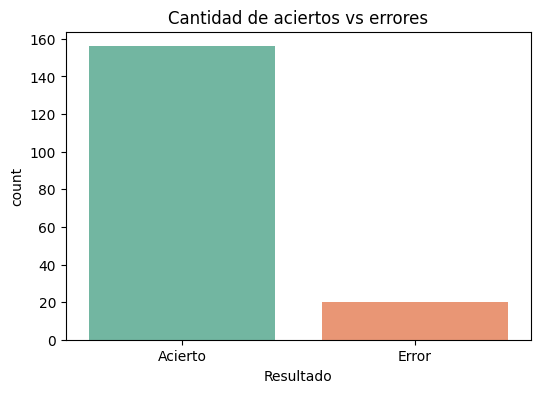

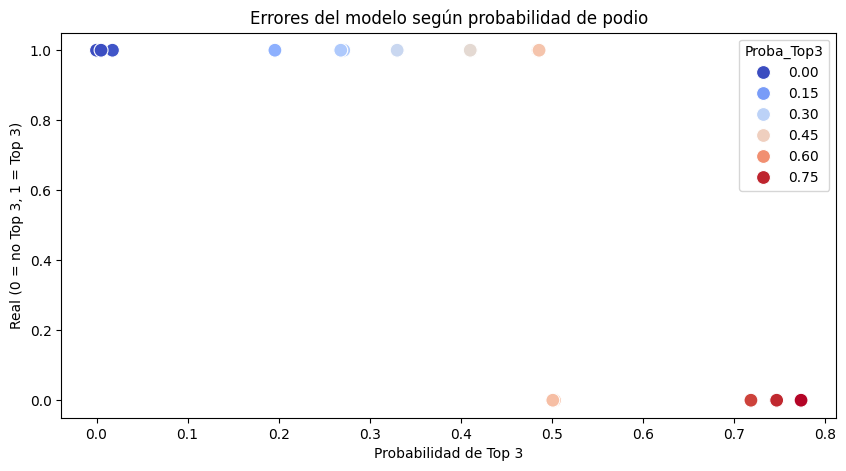

In [24]:
# Paso 1: Graficar la cantidad de errores y aciertos
plt.figure(figsize=(6,4))
sns.countplot(data=results_df, x='Resultado', palette='Set2')
plt.title('Cantidad de aciertos vs errores')
plt.show()

# Paso 2: Visualizar errores específicos en función de la probabilidad de podio
plt.figure(figsize=(10,5))
sns.scatterplot(data=errores_df, x='Proba_Top3', y='Real', hue='Proba_Top3', palette='coolwarm', s=100)
plt.title('Errores del modelo según probabilidad de podio')
plt.xlabel('Probabilidad de Top 3')
plt.ylabel('Real (0 = no Top 3, 1 = Top 3)')
plt.show()

## Matriz de confusión

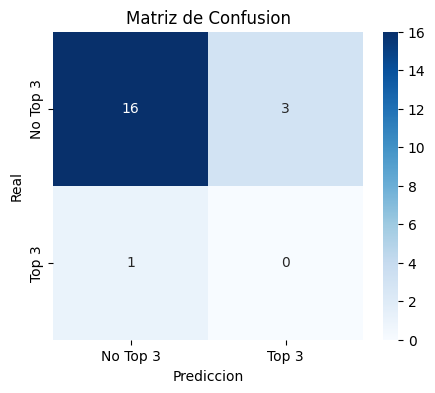

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Top 3', 'Top 3'],
            yticklabels=['No Top 3', 'Top 3'])
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.title('Matriz de Confusion')
plt.show()

Armar Dataframe con resultados

In [11]:
#Armar DataFrame con resultados
results_df = pd.DataFrame({
    'Real': y_test,
    'Prediccion':y_pred
})

results_df['Resultado'] = results_df.apply(
    lambda row: 'Acierto' if row['Real'] == row['Prediccion'] else 'Error', axis=1
)

C:\Users\Rolando Domínguez\AppData\Local\Temp\ipykernel_29536\1954863268.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=results_df, x='Resultado', palette='Set2')


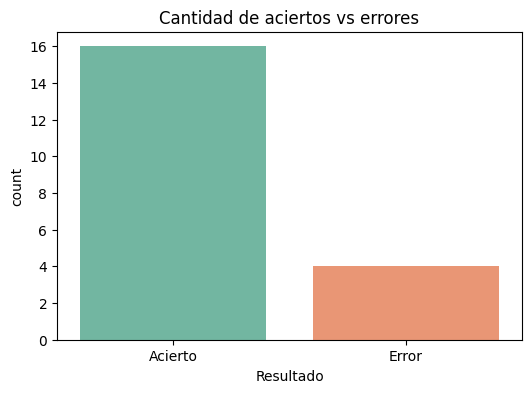

In [12]:
# Contamos cada tipo
plt.figure(figsize=(6,4))
sns.countplot(data=results_df, x='Resultado', palette='Set2')
plt.title('Cantidad de aciertos vs errores')
plt.show()

In [13]:
## Predicciones correctas por carrera
X_test = X_test.copy()
X_test['Actual'] = y_test.values
X_test['Predicted'] = y_pred
X_test['Correcto'] = X_test['Actual'] == X_test['Predicted']

# Merge con info de la carrera
X_merged = X_test.merge(df[['Race']], left_index=True, right_index=True)

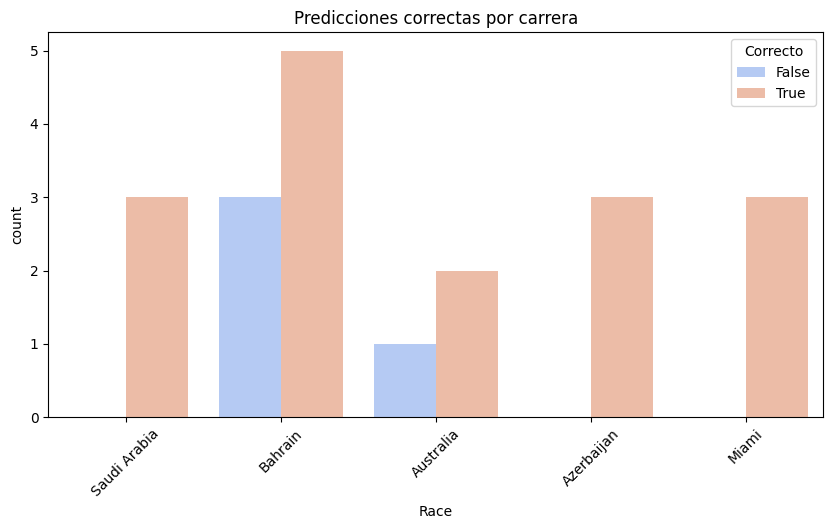

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(data=X_merged, x='Race', hue='Correcto', palette='coolwarm')
plt.title('Predicciones correctas por carrera')
plt.xticks(rotation=45)
plt.show()